# 09 — Unified Evaluation Notebook

Single evaluation script for any trained GAN (WaveNet, TimeGAN, QuantGAN, etc.).

**Protocol:**
- Evaluation in **MinMaxScaled [0,1]** space (same basis for all models)
- For `lambert` preprocessing: generator output (3×tanh → [-3,3]) is inverse-transformed (÷3 → scaler2⁻¹ → Gaussianize⁻¹ → scaler1⁻¹) then MinMaxScaled
- Real data: **non-overlapping** windows (stride = `SEQ_LEN`)
- Matched sample sizes (real = synthetic count)
- Noise distribution matches the model being evaluated

**Metrics:**
1. Distribution fidelity — MMD (multi-scale RBF), Wasserstein-1, KS test, JS divergence
2. Temporal dynamics — ACF RMSE (returns + squared returns)
3. Geometric distance — Fréchet Distance, DTW
4. Tail behaviour — Mean/Std/Skewness/Kurtosis differences
5. Discriminative score — MLP classifier
6. GRU classifier — Fidelity (accuracy + AUC on 3D sequences)
7. TSTR — Train on Synthetic, Test on Real (usefulness)
8. Visual diagnostics — PCA, t-SNE, sample sequences, distributions
9. Entropy — Shannon, Lempel-Ziv complexity, plug-in entropy
10. QuantGAN metrics — DY (log-density divergence), ACF score (3 transforms), leverage effect (Wiese et al., 2020)
11. Stylized facts — Bouchaud leverage, volatility clustering ACF, tail distribution (Hill estimator)

## 0. Configuration

Change this cell to switch between models.

In [24]:
# ============================================================
# MODEL CONFIGURATION — change this block to evaluate a
# different generator.  Everything downstream is parameterized.
# ============================================================

MODEL_NAME       = 'WaveNet-Hybrid-GAN-ml'
GENERATOR_PATH   = '../models/hybrid_wavenet_generator_ml.keras'
NOISE_TYPE       = 'normal'    # 'normal' for WaveNet / Hybrid, 'uniform' for TimeGAN
Z_DIM            = 32          # latent dimension (must match training)
SEQ_LEN          = 24         # sequence length (must match training)
N_FEATURES       = 1          # single feature: log returns
N_SAMPLES        = 100        # synthetic sequences to generate

# --- Preprocessing pipeline ---
# 'minmax'  : MinMaxScaler [0,1] — WaveNet-GAN (NB07), TimeGAN, etc.
# 'lambert' : StandardScaler → Gaussianize → StandardScaler (3-stage, no CDF) — NB12
PREPROCESSING    = 'minmax'

# --- Hybrid-specific: multi-model pipeline ---
# Set to None for single-model generators (e.g. pure WaveNet GAN)
SUPERVISOR_PATH  =  '../models/hybrid_wavenet_supervisor_ml.keras'
RECOVERY_PATH    =  '../models/hybrid_wavenet_recovery_ml.keras'

# ============================================================
# Example configs (uncomment one block):
# ============================================================
# --- WaveNet-GAN (NB07, default) ---
# MODEL_NAME     = 'WaveNet-GAN'
# GENERATOR_PATH = '../models/wavenet_generator.keras'
# PREPROCESSING  = 'minmax'
# NOISE_TYPE     = 'normal'

# --- WaveNet-GAN + Lambert W (NB12) ---
# MODEL_NAME     = 'WaveNet-GAN+Lambert'
# GENERATOR_PATH = '../models/wavenet_lambert_generator.keras'
# PREPROCESSING  = 'lambert'   # 3-stage: SS → Gaussianize → SS (no CDF)
# NOISE_TYPE     = 'normal'

# --- QuantGAN (NB11) ---
# MODEL_NAME     = 'QuantGAN'
# GENERATOR_PATH = '../models/quantgan_generator.keras'
# PREPROCESSING  = 'lambert'
# NOISE_TYPE     = 'normal'

## 1. Imports & Data Loading

In [25]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import load_model

# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Make utils importable
sys.path.append('..')
import importlib
import utils.evaluation_metrics as _eval_mod
importlib.reload(_eval_mod)
from utils.evaluation_metrics import (
    compute_mmd_per_channel,
    compute_acf_per_channel,
    compute_acf_vectors,
    compute_distribution_per_channel,
    compute_tail_metrics_per_channel,
    compute_discriminative_score,
    compute_frechet_distance,
    compute_dtw_distance,
    compute_js_divergence_3d_dynamic_bins,
)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [26]:
# Load SP500 data (identical to NB07 cell 4)
data = pd.read_csv('../data/raw/sp500.csv', index_col='Date', parse_dates=True)
data = data.apply(pd.to_numeric, errors='coerce')

close_prices = data['Close']
log_returns = np.log(close_prices / close_prices.shift(1)).dropna()
log_returns_array = log_returns.values.reshape(-1, 1)

# ── Preprocessing pipeline ──────────────────────────────────
if PREPROCESSING == 'lambert':
    from sklearn.preprocessing import StandardScaler
    from utils.gaussianize import Gaussianize

    # 3-stage Lambert W preprocessing (no CDF — removed per NB12 fix)
    # Stage 1: StandardScaler (centre + normalize)
    scaler1 = StandardScaler()
    stage1 = scaler1.fit_transform(log_returns_array)

    # Stage 2: Gaussianize (Lambert W inverse — remove heavy tails)
    gaussianizer = Gaussianize(max_iter=100, tol=1e-6)
    stage2 = gaussianizer.fit_transform(stage1)

    # Stage 3: StandardScaler (re-standardize Gaussianized output → ~N(0,1))
    scaler2 = StandardScaler()
    log_returns_gaussianized = scaler2.fit_transform(stage2.reshape(-1, 1)).astype(np.float32)

    # Generator uses 3×tanh → output range [-3, 3] to cover 99.7% of N(0,1)
    print(f"Preprocessing: StandardScaler → Gaussianize(δ={gaussianizer.delta_[0]:.6f}) → StandardScaler")
    print(f"Gaussianized range (stage 3): [{log_returns_gaussianized.min():.4f}, {log_returns_gaussianized.max():.4f}]")
    print(f"  (Generator output: 3×tanh → [-3, 3] range)")

# MinMaxScaler for evaluation space (always fitted on real data)
scaler = MinMaxScaler()
log_returns_scaled = scaler.fit_transform(log_returns_array)

# --- NON-OVERLAPPING windows (stride = SEQ_LEN) ---
# This avoids inflating sample count with near-duplicate data
n_total = len(log_returns_scaled)
n_windows = n_total // SEQ_LEN
sequences = np.array([
    log_returns_scaled[i * SEQ_LEN : (i + 1) * SEQ_LEN]
    for i in range(n_windows)
], dtype=np.float32)  # shape: (n_windows, SEQ_LEN, 1)

print(f"Total log returns: {n_total}")
print(f"Non-overlapping windows (stride={SEQ_LEN}): {sequences.shape}")
print(f"Scaled range: [{sequences.min():.4f}, {sequences.max():.4f}]")

Total log returns: 6036
Non-overlapping windows (stride=24): (251, 24, 1)
Scaled range: [0.0000, 1.0000]


## 2. Load Generator & Generate Synthetic Data

In [27]:
# Load generator
# safe_mode=False needed for Lambda layers (e.g. 3×tanh in WaveNet-Lambert)
generator = load_model(GENERATOR_PATH, safe_mode=False)
print(f"Loaded generator from {GENERATOR_PATH}")
print(f"  Input shape:  {generator.input_shape}")
print(f"  Output shape: {generator.output_shape}")

# --- Load supervisor + recovery for hybrid pipeline ---
supervisor, recovery_net = None, None
if SUPERVISOR_PATH and RECOVERY_PATH:
    supervisor = load_model(SUPERVISOR_PATH, safe_mode=False)
    recovery_net = load_model(RECOVERY_PATH, safe_mode=False)
    print(f"Loaded supervisor from {SUPERVISOR_PATH}")
    print(f"Loaded recovery  from {RECOVERY_PATH}")
    print(f"  Pipeline: Z → Generator → Supervisor → Recovery → X̃")
else:
    print(f"  Pipeline: Z → Generator → X̃  (single model)")

# Match sample count to real non-overlapping windows
n_eval = min(N_SAMPLES, len(sequences))

# Generate noise (distribution matches training)
if NOISE_TYPE == 'normal':
    Z = tf.random.normal(shape=(n_eval, SEQ_LEN, Z_DIM), mean=0.0, stddev=1.0)
elif NOISE_TYPE == 'uniform':
    Z = tf.random.uniform(shape=(n_eval, SEQ_LEN, Z_DIM), minval=0.0, maxval=1.0)
else:
    raise ValueError(f"Unknown NOISE_TYPE: {NOISE_TYPE}")

# Generate synthetic data
if supervisor is not None and recovery_net is not None:
    # Hybrid pipeline: Generator → Supervisor → Recovery
    E_hat = generator(Z, training=False)
    H_hat = supervisor(E_hat, training=False)
    raw_synthetic = recovery_net(H_hat, training=False).numpy()
    print(f"Generated (hybrid pipeline): {raw_synthetic.shape}")
else:
    raw_synthetic = generator(Z, training=False).numpy()
    print(f"Generated (direct): {raw_synthetic.shape}")

print(f"  Range: [{raw_synthetic.min():.6f}, {raw_synthetic.max():.6f}]")

# ── Inverse-transform synthetic data to evaluation space ──
if PREPROCESSING == 'lambert':
    # Generator uses 3×tanh activation → output IS the Gaussianized prediction
    # (analogous to sigmoid → [0,1] for MinMax — no inverse activation needed)
    synth_gauss = raw_synthetic.squeeze()
    print(f"  Gaussianized synth range: [{synth_gauss.min():.4f}, {synth_gauss.max():.4f}]")
    # Inverse Stage 3: undo re-standardization
    synth_stage2 = scaler2.inverse_transform(synth_gauss.reshape(-1, 1)).reshape(synth_gauss.shape)
    # Inverse Stage 2: undo Gaussianize
    synth_stage1 = gaussianizer.inverse_transform(synth_stage2.reshape(-1, 1)).reshape(synth_gauss.shape)
    # Inverse Stage 1: undo first StandardScaler → back to original log-return scale
    synth_original = scaler1.inverse_transform(synth_stage1.reshape(-1, 1)).reshape(synth_gauss.shape)
    # Now map into [0,1] evaluation space using the MinMaxScaler fitted on real data
    synthetic_sequences = scaler.transform(synth_original.reshape(-1, 1)).reshape(raw_synthetic.shape).astype(np.float32)
    print(f"Lambert inverse → MinMax evaluation space: [{synthetic_sequences.min():.4f}, {synthetic_sequences.max():.4f}]")
elif PREPROCESSING == 'minmax':
    # Direct: generator output is already in [0,1] evaluation space
    synthetic_sequences = raw_synthetic.astype(np.float32)
    print(f"MinMax evaluation space: [{synthetic_sequences.min():.4f}, {synthetic_sequences.max():.4f}]")
else:
    raise ValueError(f"Unknown PREPROCESSING: {PREPROCESSING}")

# Subsample real sequences to match
real_sequences = sequences[:n_eval]
print(f"\nReal sequences:      {real_sequences.shape}")
print(f"Synthetic sequences: {synthetic_sequences.shape}")

# Flatten to 2-D (n_samples, seq_len) for downstream metrics
real_2d = real_sequences.squeeze(-1)       # (n_eval, SEQ_LEN)
synth_2d = synthetic_sequences.squeeze(-1) # (n_eval, SEQ_LEN)
print(f"real_2d:  {real_2d.shape}   synth_2d: {synth_2d.shape}")

Loaded generator from ../models/hybrid_wavenet_generator_ml.keras
  Input shape:  (None, 24, 32)
  Output shape: (None, 24, 24)
Loaded supervisor from ../models/hybrid_wavenet_supervisor_ml.keras
Loaded recovery  from ../models/hybrid_wavenet_recovery_ml.keras
  Pipeline: Z → Generator → Supervisor → Recovery → X̃
Generated (hybrid pipeline): (100, 24, 1)
  Range: [0.409024, 0.999772]
MinMax evaluation space: [0.4090, 0.9998]

Real sequences:      (100, 24, 1)
Synthetic sequences: (100, 24, 1)
real_2d:  (100, 24)   synth_2d: (100, 24)


## 3. Summary Statistics (Sanity Check)

In [28]:
# Quick sanity check before running expensive metrics
# All stats computed in [0,1] scaled space
stats = pd.DataFrame({
    'Real': [real_2d.mean(), real_2d.std(), real_2d.min(), real_2d.max(),
             np.median(real_2d)],
    'Synthetic': [synth_2d.mean(), synth_2d.std(), synth_2d.min(), synth_2d.max(),
                  np.median(synth_2d)],
}, index=['Mean', 'Std', 'Min', 'Max', 'Median'])
stats['Delta'] = stats['Synthetic'] - stats['Real']

print(f"Summary Statistics (scaled [0,1] space) — {MODEL_NAME}")
print(stats.to_string(float_format='{:.6f}'.format))

# Also show stats in original log-return space for interpretability
real_rescaled = scaler.inverse_transform(real_2d.reshape(-1, 1)).flatten()
synth_rescaled = scaler.inverse_transform(synth_2d.reshape(-1, 1)).flatten()

stats_raw = pd.DataFrame({
    'Real': [real_rescaled.mean(), real_rescaled.std(), real_rescaled.min(),
             real_rescaled.max()],
    'Synthetic': [synth_rescaled.mean(), synth_rescaled.std(), synth_rescaled.min(),
                  synth_rescaled.max()],
}, index=['Mean', 'Std', 'Min', 'Max'])
stats_raw['Delta'] = stats_raw['Synthetic'] - stats_raw['Real']

print(f"\nSummary Statistics (original log-return space)")
print(stats_raw.to_string(float_format='{:.6f}'.format))
if PREPROCESSING == 'lambert':
    print(f"\n  (Lambert W inverse applied before MinMaxScale — values are in original space)")

Summary Statistics (scaled [0,1] space) — WaveNet-Hybrid-GAN-ml
           Real  Synthetic     Delta
Mean   0.537367   0.772749  0.235381
Std    0.059700   0.222116  0.162415
Min    0.138928   0.409024  0.270096
Max    1.000000   0.999772 -0.000228
Median 0.539908   0.838207  0.298299

Summary Statistics (original log-return space)
          Real  Synthetic     Delta
Mean -0.000176   0.055662  0.055838
Std   0.014162   0.052691  0.038529
Min  -0.094695  -0.030622  0.064073
Max   0.109572   0.109518 -0.000054


## 4A. Distribution Fidelity

MMD (multi-scale RBF), Wasserstein-1, KS test, JS divergence.

In [29]:
# ============================================
# MMD (multi-scale RBF, per-channel)
# ============================================
mmd_results = compute_mmd_per_channel(real_sequences, synthetic_sequences,
                                       num_samples=n_eval)
print(f"MMD (multi-scale RBF): {mmd_results['mean']:.6f}")
for ch, val in mmd_results.items():
    if ch != 'mean':
        print(f"  {ch}: {val:.6f}")

# ============================================
# Wasserstein-1 & KS test
# ============================================
dist_results = compute_distribution_per_channel(real_sequences, synthetic_sequences)
print(f"\nWasserstein-1 (mean): {dist_results['mean_wasserstein']:.6f}")
print(f"KS statistic (mean): {dist_results['mean_ks']:.4f}")
for ch in dist_results['wasserstein']:
    print(f"  {ch}: W={dist_results['wasserstein'][ch]:.6f}, "
          f"KS={dist_results['ks_statistic'][ch]:.4f}, "
          f"p={dist_results['ks_pvalue'][ch]:.4f}")

# ============================================
# JS Divergence
# ============================================
js_similarity = compute_js_divergence_3d_dynamic_bins(real_sequences, synthetic_sequences)
js_divergence = (100 - js_similarity) / 100  # Convert back to [0,1] divergence
print(f"\nJS Divergence: {js_divergence:.6f}")
print(f"JS Similarity: {js_similarity:.2f}%")

MMD (multi-scale RBF): 0.823072
  Open: 0.823072

Wasserstein-1 (mean): 0.235381
KS statistic (mean): 0.5167
  Open: W=0.235381, KS=0.5167, p=0.0000

JS Divergence: 0.572466
JS Similarity: 42.75%


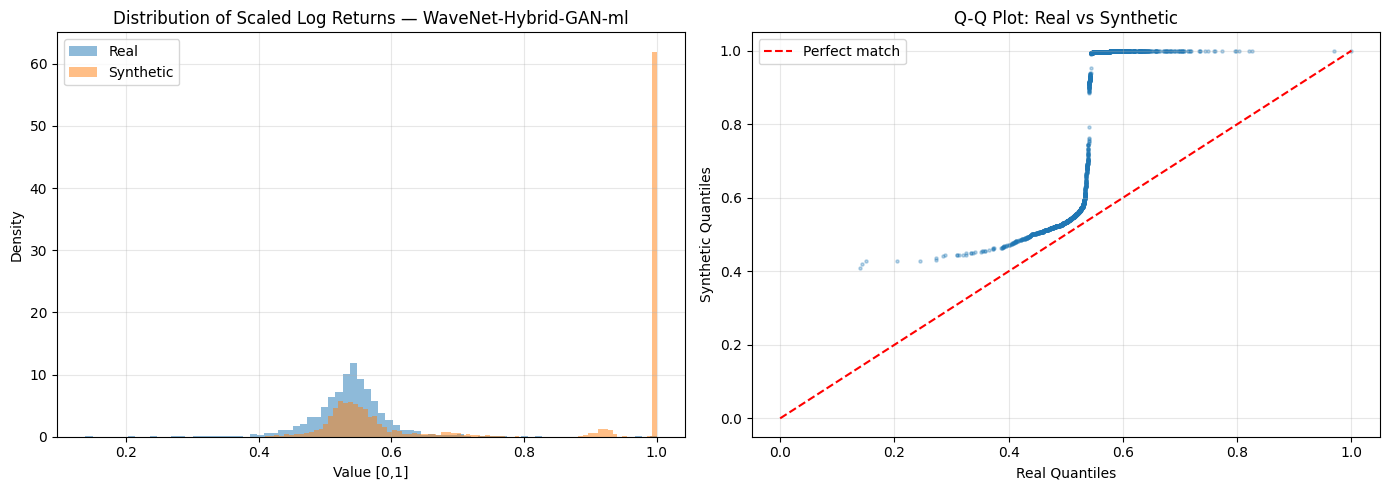

In [30]:
# Distribution plots — histogram + QQ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of scaled values (all time-steps pooled)
axes[0].hist(real_2d.flatten(), bins=80, alpha=0.5, density=True, label='Real')
axes[0].hist(synth_2d.flatten(), bins=80, alpha=0.5, density=True, label='Synthetic')
axes[0].set_title(f'Distribution of Scaled Log Returns — {MODEL_NAME}')
axes[0].set_xlabel('Value [0,1]')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# QQ plot
real_sorted = np.sort(real_2d.flatten())
synth_sorted = np.sort(synth_2d.flatten())
n_qq = min(len(real_sorted), len(synth_sorted))
axes[1].scatter(
    real_sorted[np.linspace(0, len(real_sorted)-1, n_qq, dtype=int)],
    synth_sorted[np.linspace(0, len(synth_sorted)-1, n_qq, dtype=int)],
    alpha=0.3, s=5
)
axes[1].plot([0, 1], [0, 1], 'r--', label='Perfect match')
axes[1].set_title('Q-Q Plot: Real vs Synthetic')
axes[1].set_xlabel('Real Quantiles')
axes[1].set_ylabel('Synthetic Quantiles')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4B. Temporal Dynamics

Autocorrelation RMSE for returns and squared returns (volatility clustering).

ACF RMSE (returns):         0.365612
ACF RMSE (squared returns): 0.363369


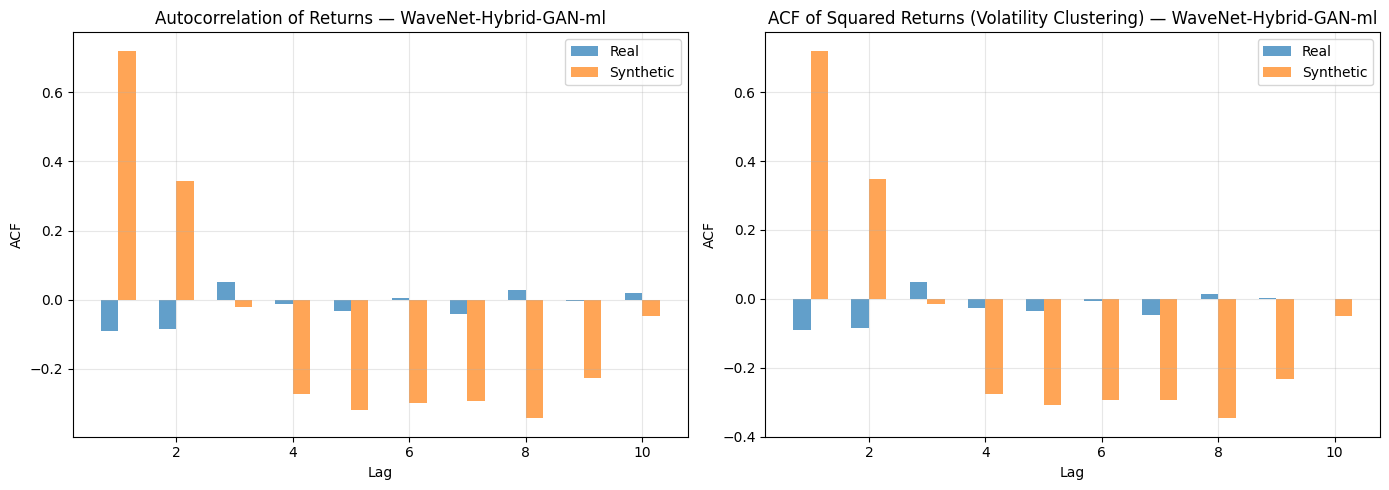

In [31]:
# ACF comparison — uses compute_acf_vectors for plotting
acf = compute_acf_vectors(real_sequences, synthetic_sequences, max_lag=10)
lags = acf['lags']

# Also get scalar RMSE from compute_acf_per_channel (for summary table later)
acf_rmse_results = compute_acf_per_channel(real_sequences, synthetic_sequences, max_lag=10)

# Get the first (only) channel
ch_name = list(acf['returns'].keys())[0]
ret = acf['returns'][ch_name]
sq = acf['squared'][ch_name]

print(f"ACF RMSE (returns):         {ret['rmse']:.6f}")
print(f"ACF RMSE (squared returns): {sq['rmse']:.6f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(lags - 0.15, ret['real'], width=0.3, label='Real', alpha=0.7)
axes[0].bar(lags + 0.15, ret['synthetic'], width=0.3, label='Synthetic', alpha=0.7)
axes[0].set_title(f'Autocorrelation of Returns — {MODEL_NAME}')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('ACF')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(lags - 0.15, sq['real'], width=0.3, label='Real', alpha=0.7)
axes[1].bar(lags + 0.15, sq['synthetic'], width=0.3, label='Synthetic', alpha=0.7)
axes[1].set_title(f'ACF of Squared Returns (Volatility Clustering) — {MODEL_NAME}')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('ACF')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4C. Geometric / Embedding Distance

Fréchet Distance (joint) and DTW.

In [32]:
# ============================================
# Fréchet Distance (joint, per-channel)
# ============================================
fd_results = compute_frechet_distance(real_sequences, synthetic_sequences, per_channel=True)
print(f"Fréchet Distance (joint):       {fd_results['overall_fd']:.6f}")
print(f"Fréchet Distance (avg channel): {fd_results['average_channel_fd']:.6f}")
for ch, val in fd_results['channel_fd'].items():
    print(f"  {ch}: {val:.6f}")

# ============================================
# DTW Distance (subsampled for speed)
# ============================================
n_dtw = min(50, n_eval)  # DTW is O(n²) per pair — subsample
dtw_real = real_sequences[:n_dtw]
dtw_synth = synthetic_sequences[:n_dtw]
dtw_score = compute_dtw_distance(dtw_real, dtw_synth)
print(f"\nDTW Distance (mean, n={n_dtw}): {dtw_score:.6f}")

Fréchet Distance (joint):       0.081792
Fréchet Distance (avg channel): 0.081781
  Channel_0: 0.081781

DTW Distance (mean, n=50): 21.422676


## 4D. Tail Behaviour & Higher-Order Statistics

Mean, std, skewness, and kurtosis differences — critical for financial risk modelling.

Tail metrics (Open):
  Mean diff:      0.235381
  Std ratio:      3.7205  (1.0 = perfect)
  Skewness diff:  0.0177
  Kurtosis diff:  9.5097


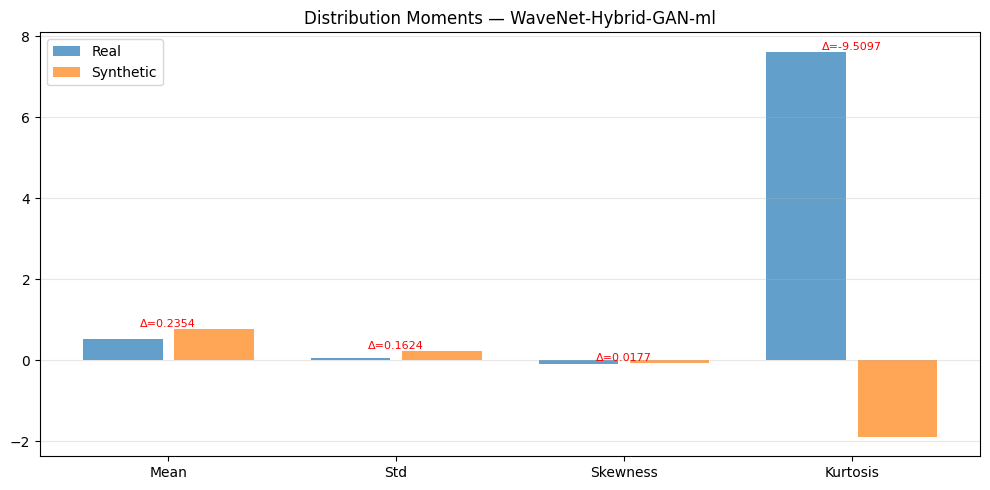

In [33]:
from scipy.stats import skew, kurtosis

tail_results = compute_tail_metrics_per_channel(real_sequences, synthetic_sequences)

ch_name = list(tail_results['mean_diff'].keys())[0]
print(f"Tail metrics ({ch_name}):")
print(f"  Mean diff:      {tail_results['mean_diff'][ch_name]:.6f}")
print(f"  Std ratio:      {tail_results['std_ratio'][ch_name]:.4f}  (1.0 = perfect)")
print(f"  Skewness diff:  {tail_results['skew_diff'][ch_name]:.4f}")
print(f"  Kurtosis diff:  {tail_results['kurtosis_diff'][ch_name]:.4f}")

# Bar chart — real vs synthetic moment values
real_flat = real_2d.flatten()
synth_flat = synth_2d.flatten()
moment_names = ['Mean', 'Std', 'Skewness', 'Kurtosis']
real_moments = [np.mean(real_flat), np.std(real_flat),
                skew(real_flat), kurtosis(real_flat)]
synth_moments = [np.mean(synth_flat), np.std(synth_flat),
                 skew(synth_flat), kurtosis(synth_flat)]

x = np.arange(len(moment_names))
fig, ax = plt.subplots(figsize=(10, 5))
bars_r = ax.bar(x - 0.2, real_moments, 0.35, label='Real', alpha=0.7)
bars_s = ax.bar(x + 0.2, synth_moments, 0.35, label='Synthetic', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(moment_names)
ax.set_title(f'Distribution Moments — {MODEL_NAME}')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Annotate deltas
for i, (r, s) in enumerate(zip(real_moments, synth_moments)):
    delta = s - r
    ax.annotate(f'Δ={delta:.4f}', xy=(i, max(r, s)),
                ha='center', va='bottom', fontsize=8, color='red')

plt.tight_layout()
plt.show()

## 4E. Discriminative Score

MLP classifier trained to distinguish real from synthetic.  
Score = |accuracy − 0.5|. Lower = better (indistinguishable).

In [34]:
disc_results = compute_discriminative_score(real_sequences, synthetic_sequences)
print(f"Discriminative Accuracy: {disc_results['accuracy']:.4f}")
print(f"Discriminative Score:    {disc_results['score']:.4f}  (closer to 0 = better)")

Discriminative Accuracy: 1.0000
Discriminative Score:    0.5000  (closer to 0 = better)


## 4F. GRU Classifier — Fidelity Assessment

A GRU-based time series classifier trained to distinguish real from synthetic
sequences on the **full 3D data** (preserving temporal structure).  
Adapted from the original TimeGAN evaluation (Yoon et al. 2019).

GRU Classifier — Test Accuracy: 1.0000, AUC: 1.0000, Score: 0.5000


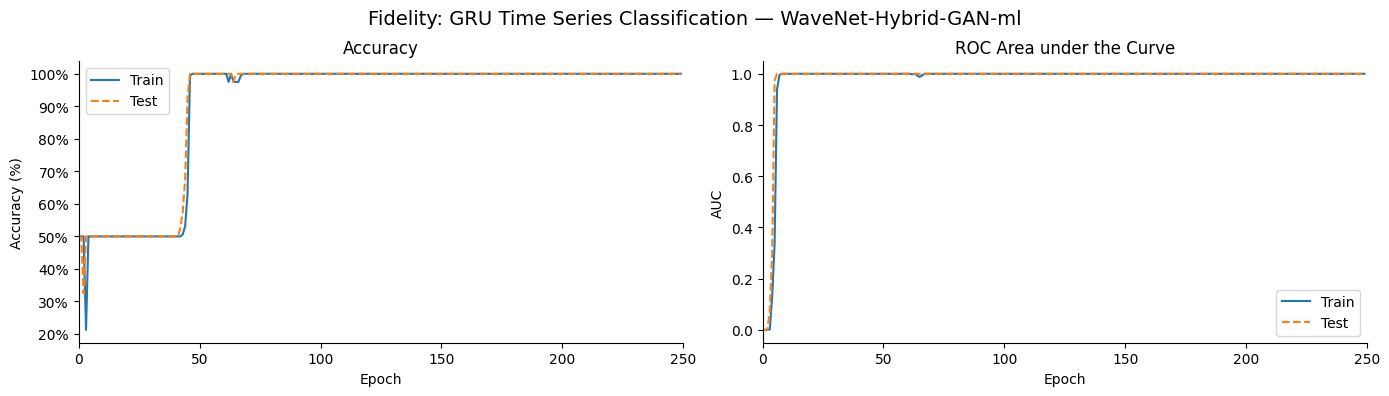

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Input
from tensorflow.keras.metrics import AUC
from matplotlib.ticker import FuncFormatter

# --- Prepare labelled dataset (3D) ---
n_series = n_eval
idx = np.arange(n_series)
n_train = int(0.8 * n_series)
train_idx, test_idx = idx[:n_train], idx[n_train:]

train_data = np.vstack((real_sequences[train_idx], synthetic_sequences[train_idx]))
test_data  = np.vstack((real_sequences[test_idx],  synthetic_sequences[test_idx]))

n_train_cls, n_test_cls = len(train_idx), len(test_idx)
train_labels = np.concatenate([np.ones(n_train_cls), np.zeros(n_train_cls)])
test_labels  = np.concatenate([np.ones(n_test_cls),  np.zeros(n_test_cls)])

# --- Build GRU classifier ---
gru_classifier = Sequential([
    Input(shape=(SEQ_LEN, N_FEATURES)),
    GRU(24, name='GRU'),
    Dense(1, activation='sigmoid', name='OUT')
], name='TS_Classifier')

gru_classifier.compile(loss='binary_crossentropy',
                       optimizer='adam',
                       metrics=[AUC(name='AUC'), 'accuracy'])

gru_result = gru_classifier.fit(
    x=train_data, y=train_labels,
    validation_data=(test_data, test_labels),
    epochs=250, batch_size=128, verbose=0
)

gru_test_loss, gru_test_auc, gru_test_acc = gru_classifier.evaluate(
    test_data, test_labels, verbose=0
)
gru_disc_score = abs(0.5 - gru_test_acc)

print(f"GRU Classifier — Test Accuracy: {gru_test_acc:.4f}, "
      f"AUC: {gru_test_auc:.4f}, Score: {gru_disc_score:.4f}")

# --- Plot training curves ---
history = pd.DataFrame(gru_result.history)
fig, axes = plt.subplots(ncols=2, figsize=(14, 4))

history[['accuracy', 'val_accuracy']].rename(
    columns={'accuracy': 'Train', 'val_accuracy': 'Test'}
).plot(ax=axes[0], title='Accuracy', style=['-', '--'], xlim=(0, 250))
axes[0].set_xlabel('Epoch')
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0].set_ylabel('Accuracy (%)')

history[['AUC', 'val_AUC']].rename(
    columns={'AUC': 'Train', 'val_AUC': 'Test'}
).plot(ax=axes[1], title='ROC Area under the Curve',
       style=['-', '--'], xlim=(0, 250))
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')

sns.despine()
fig.suptitle(f'Fidelity: GRU Time Series Classification — {MODEL_NAME}', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.85)
plt.show()

## 4G. TSTR — Train on Synthetic, Test on Real (Usefulness)

Train a GRU regression model to predict the next time step.  
Compare: model trained on **synthetic** vs model trained on **real** data,  
both tested on held-out real data.  If the synthetic-trained model performs  
comparably, the synthetic data is *useful* for downstream ML tasks.

TSTR MAE (Train Synthetic, Test Real): 0.159769
TRTR MAE (Train Real, Test Real):      0.059910
TSTR / TRTR ratio:                     2.6668  (closer to 1.0 = better)


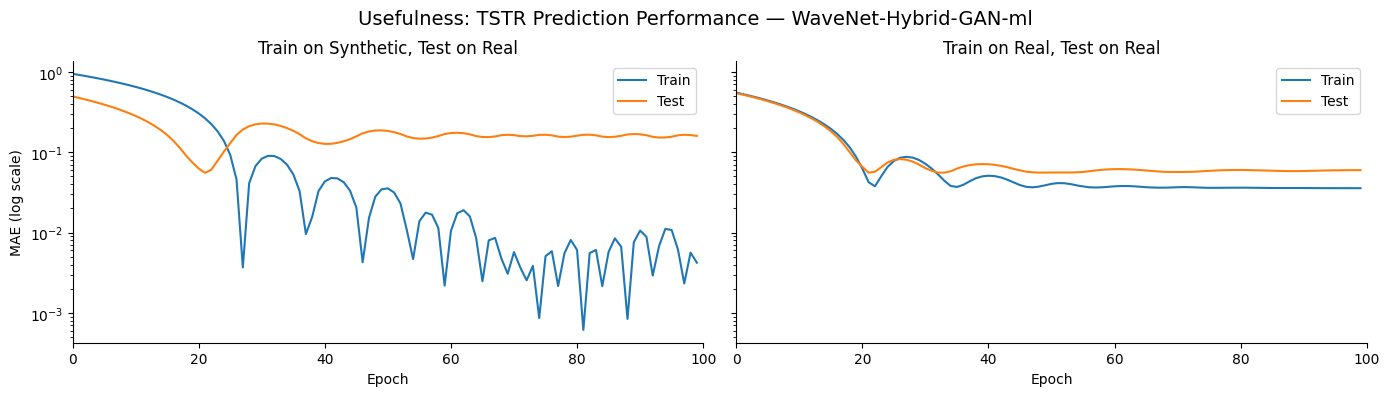

In [36]:
from tensorflow.keras.losses import MeanAbsoluteError
from tensorflow.keras.optimizers import Adam

# --- Split sequences: input = t[0:-1], label = t[-1] ---
real_train_X = real_sequences[train_idx, :-1, :]   # (n_train, SEQ_LEN-1, 1)
real_train_y = real_sequences[train_idx, -1, :]     # (n_train, 1)
real_test_X  = real_sequences[test_idx, :-1, :]
real_test_y  = real_sequences[test_idx, -1, :]

synth_train_X = synthetic_sequences[:, :-1, :]      # use all synthetic for training
synth_train_y = synthetic_sequences[:, -1, :]

def build_predictor():
    model = Sequential([
        Input(shape=(SEQ_LEN - 1, N_FEATURES)),
        GRU(24),
        Dense(N_FEATURES)
    ])
    model.compile(optimizer=Adam(), loss=MeanAbsoluteError(name='MAE'))
    return model

# --- Train on Synthetic, Test on Real ---
tstr_model = build_predictor()
tstr_result = tstr_model.fit(
    x=synth_train_X, y=synth_train_y,
    validation_data=(real_test_X, real_test_y),
    epochs=100, batch_size=128, verbose=0
)
tstr_mae = tstr_model.evaluate(real_test_X, real_test_y, verbose=0)

# --- Train on Real, Test on Real (baseline) ---
trtr_model = build_predictor()
trtr_result = trtr_model.fit(
    x=real_train_X, y=real_train_y,
    validation_data=(real_test_X, real_test_y),
    epochs=100, batch_size=128, verbose=0
)
trtr_mae = trtr_model.evaluate(real_test_X, real_test_y, verbose=0)

print(f"TSTR MAE (Train Synthetic, Test Real): {tstr_mae:.6f}")
print(f"TRTR MAE (Train Real, Test Real):      {trtr_mae:.6f}")
print(f"TSTR / TRTR ratio:                     {tstr_mae / trtr_mae:.4f}  (closer to 1.0 = better)")

# --- Plot training curves ---
tstr_hist = pd.DataFrame(tstr_result.history).rename(columns={'loss': 'Train', 'val_loss': 'Test'})
trtr_hist = pd.DataFrame(trtr_result.history).rename(columns={'loss': 'Train', 'val_loss': 'Test'})

fig, axes = plt.subplots(ncols=2, figsize=(14, 4), sharey=True)
tstr_hist.plot(ax=axes[0], title='Train on Synthetic, Test on Real',
               logy=True, xlim=(0, 100))
trtr_hist.plot(ax=axes[1], title='Train on Real, Test on Real',
               logy=True, xlim=(0, 100))
for i in [0, 1]:
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('MAE (log scale)')

sns.despine()
fig.suptitle(f'Usefulness: TSTR Prediction Performance — {MODEL_NAME}', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.85)
plt.show()

## 5. Visual Diagnostics

PCA, t-SNE, and sample sequence comparison.

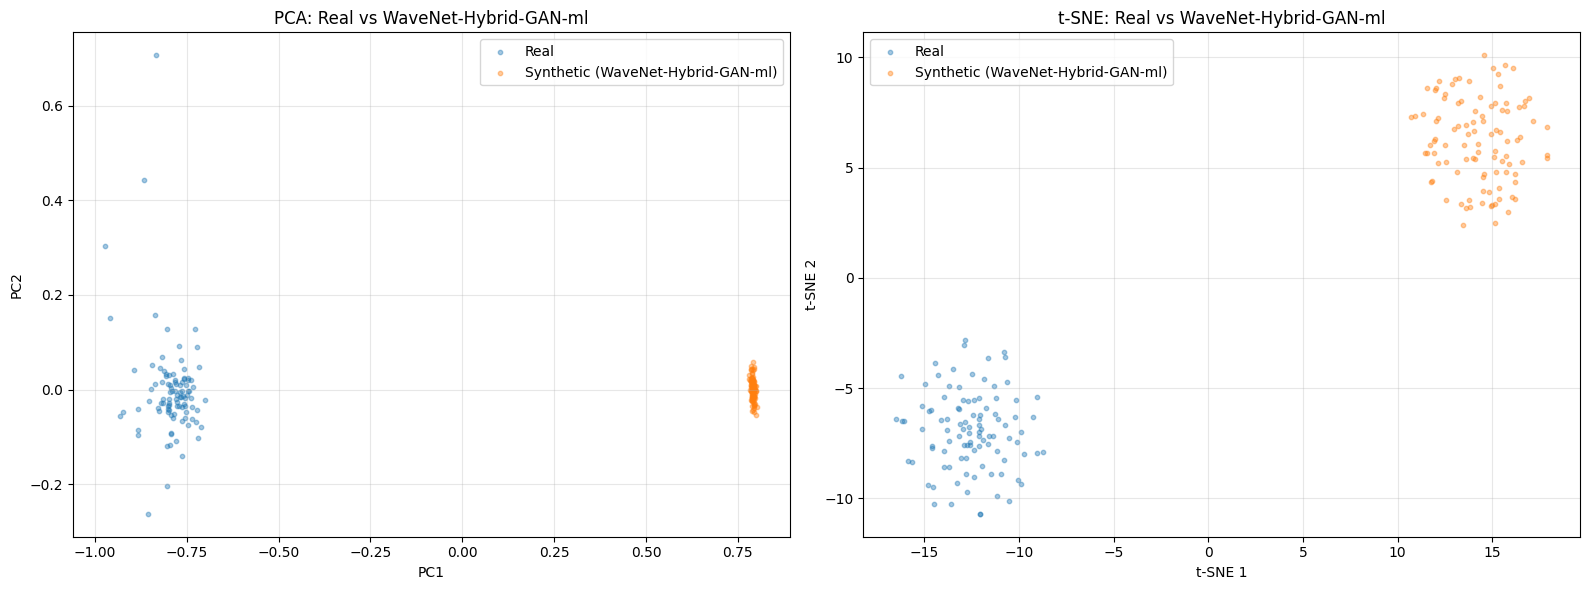

In [37]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Combine real & synthetic 2D arrays
combined = np.vstack([real_2d, synth_2d])
labels = np.array([0] * n_eval + [1] * n_eval)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(combined)
axes[0].scatter(pca_result[labels==0, 0], pca_result[labels==0, 1],
                alpha=0.4, label='Real', s=10)
axes[0].scatter(pca_result[labels==1, 0], pca_result[labels==1, 1],
                alpha=0.4, label=f'Synthetic ({MODEL_NAME})', s=10)
axes[0].set_title(f'PCA: Real vs {MODEL_NAME}')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# t-SNE (subsample for speed)
n_tsne = min(500, n_eval)
idx_real = np.random.choice(n_eval, n_tsne, replace=n_tsne > n_eval)
idx_synth = np.random.choice(n_eval, n_tsne, replace=n_tsne > n_eval) + n_eval
idx_all = np.concatenate([idx_real, idx_synth])

tsne = TSNE(n_components=2, perplexity=min(30, n_tsne - 1), random_state=42)
tsne_result = tsne.fit_transform(combined[idx_all])
tsne_labels = labels[idx_all]

axes[1].scatter(tsne_result[tsne_labels==0, 0], tsne_result[tsne_labels==0, 1],
                alpha=0.4, label='Real', s=10)
axes[1].scatter(tsne_result[tsne_labels==1, 0], tsne_result[tsne_labels==1, 1],
                alpha=0.4, label=f'Synthetic ({MODEL_NAME})', s=10)
axes[1].set_title(f't-SNE: Real vs {MODEL_NAME}')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

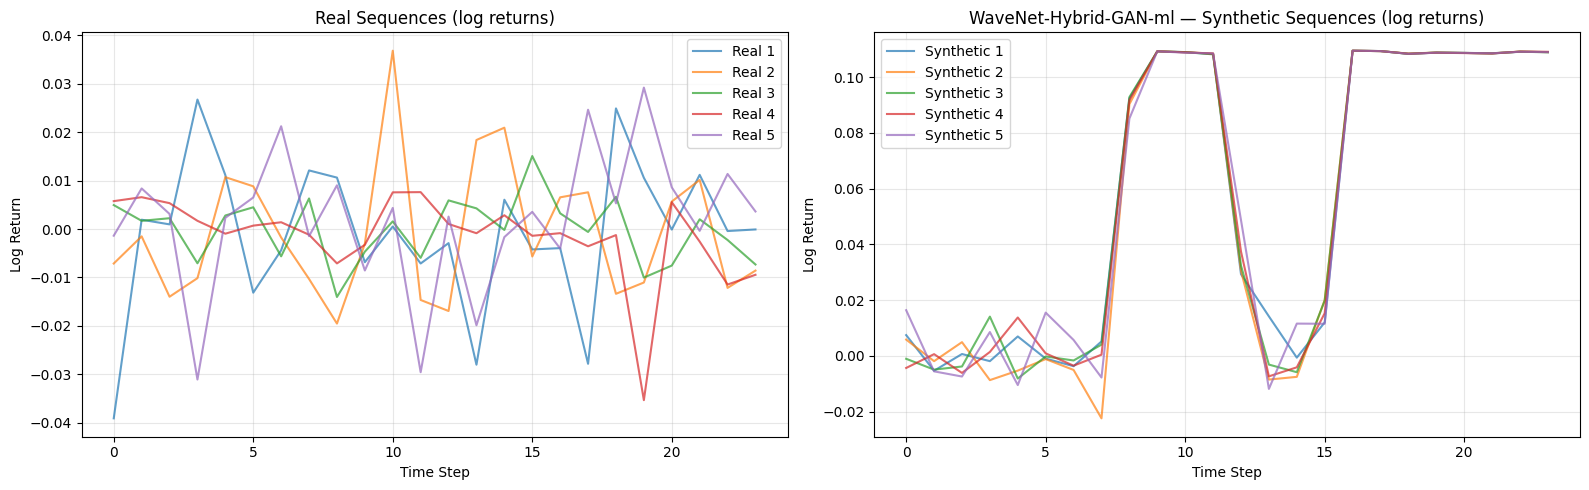

In [38]:
# Sample sequences — 5 real vs 5 synthetic (in original log-return space)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Pick 5 well-separated real windows
plot_idx = np.linspace(0, n_eval - 1, 5, dtype=int)

# Rescale to log-return space for interpretability
real_plot = scaler.inverse_transform(
    real_sequences[plot_idx].reshape(-1, 1)
).reshape(5, SEQ_LEN)
synth_plot = scaler.inverse_transform(
    synthetic_sequences[:5].reshape(-1, 1)
).reshape(5, SEQ_LEN)

for i in range(5):
    axes[0].plot(real_plot[i], alpha=0.7, label=f'Real {i+1}')
axes[0].set_title('Real Sequences (log returns)')
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Log Return')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for i in range(5):
    axes[1].plot(synth_plot[i], alpha=0.7, label=f'Synthetic {i+1}')
axes[1].set_title(f'{MODEL_NAME} — Synthetic Sequences (log returns)')
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Log Return')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5b. Entropy Analysis

Compare the information-theoretic structure of real vs synthetic sequences using three complementary entropy measures:

- **Shannon Entropy** — measures marginal randomness of the discretised series
- **Lempel-Ziv Complexity** — captures pattern/substring diversity (mode-collapse detector)
- **Plug-in Entropy (word=2)** — captures transition / bigram structure

Values are computed after quantile-binning each series into 5 equal-frequency bins. A good generator should closely match the real data's entropy on all three measures.

In [39]:
from utils.evaluation_metrics import compute_entropy_metrics

entropy_results = compute_entropy_metrics(real_sequences, synthetic_sequences, n_bins=5)

ch = list(entropy_results['shannon_real'].keys())[0]

print("=" * 65)
print(f"  {MODEL_NAME} — Entropy Analysis")
print("=" * 65)
print(f"  {'Metric':<35} {'Real':>10} {'Synth':>10} {'|Δ|':>10}")
print("-" * 65)
print(f"  {'Shannon Entropy (bits)':<35} "
      f"{entropy_results['shannon_real'][ch]:>10.4f} "
      f"{entropy_results['shannon_synth'][ch]:>10.4f} "
      f"{entropy_results['shannon_diff'][ch]:>10.4f}")
print(f"  {'Lempel-Ziv Complexity':<35} "
      f"{entropy_results['lz_real'][ch]:>10.4f} "
      f"{entropy_results['lz_synth'][ch]:>10.4f} "
      f"{entropy_results['lz_diff'][ch]:>10.4f}")
print(f"  {'Plug-in Entropy (w=2, bits)':<35} "
      f"{entropy_results['plugin2_real'][ch]:>10.4f} "
      f"{entropy_results['plugin2_synth'][ch]:>10.4f} "
      f"{entropy_results['plugin2_diff'][ch]:>10.4f}")
print("=" * 65)

# Interpretation
lz_ratio = entropy_results['lz_synth'][ch] / max(entropy_results['lz_real'][ch], 1e-8)
if lz_ratio < 0.85:
    print("\n  ⚠  LZ complexity is significantly LOWER than real data → possible mode collapse")
elif lz_ratio > 1.15:
    print("\n  ⚠  LZ complexity is significantly HIGHER than real data → over-random / noisy")
else:
    print("\n  ✓  LZ complexity is within 15% of real data → good pattern diversity")

sh_diff = entropy_results['shannon_diff'][ch]
if sh_diff < 0.05:
    print("  ✓  Shannon entropy match is excellent (Δ < 0.05 bits)")
elif sh_diff < 0.15:
    print("  ~  Shannon entropy match is acceptable (Δ < 0.15 bits)")
else:
    print(f"  ⚠  Shannon entropy gap is large (Δ = {sh_diff:.4f} bits)")

  WaveNet-Hybrid-GAN-ml — Entropy Analysis
  Metric                                    Real      Synth        |Δ|
-----------------------------------------------------------------
  Shannon Entropy (bits)                  2.3219     1.6633     0.6586
  Lempel-Ziv Complexity                   0.2525     0.1717     0.0808
  Plug-in Entropy (w=2, bits)             4.6207     3.1138     1.5069

  ⚠  LZ complexity is significantly LOWER than real data → possible mode collapse
  ⚠  Shannon entropy gap is large (Δ = 0.6586 bits)


## 5c. QuantGAN-style Metrics (Wiese et al., 2020)

Three metrics from the original Quant GANs paper (arXiv:1907.06673):

- **DY metric** (Drǎgulescu & Yakovenko, 2002) — log-density divergence at multiple time lags (1, 5, 20 days). Measures distributional fidelity across different return horizons.
- **ACF score** — L2 norm of ACF difference for three transforms: $f(x) = x$ (serial), $f(x) = x^2$ (squared/vol clustering), $f(x) = |x|$ (absolute). Captures temporal dependence structure.
- **Leverage effect score** — Compares $\text{Corr}(r_{t+\tau}^2, r_t)$ curves. Captures the asymmetric negative correlation between volatility and returns (a key stylized fact).

  WaveNet-Hybrid-GAN-ml — QuantGAN Metrics (Wiese et al., 2020)

  DY Metric (log-density divergence, lower = better):
    DY(1)           49.6981
    DY(5)          127.4891
    DY(20)         129.7852
    DY(100)        140.4000

  ACF Score — MinMax [0,1] windowed (windowed, K=23 lags):
    Metric                         L2 (QuantGAN) MSE (MiT-WGAN)
    --------------------------------------------------------
    ACF(x)  — serial                     1.2145       6.41e-02
    ACF(x²) — squared                    1.2231       6.50e-02
    ACF(|x|) — absolute                  1.2145       6.41e-02

  ACF Score — Original log-returns (windowed, K=23 lags):
    Metric                         L2 (QuantGAN) MSE (MiT-WGAN)
    --------------------------------------------------------
    ACF(x)  — serial                     1.2145       6.41e-02
    ACF(x²) — squared                    1.2017       6.28e-02
    ACF(|x|) — absolute                  1.2379       6.66e-02

  ACF Score — Origina

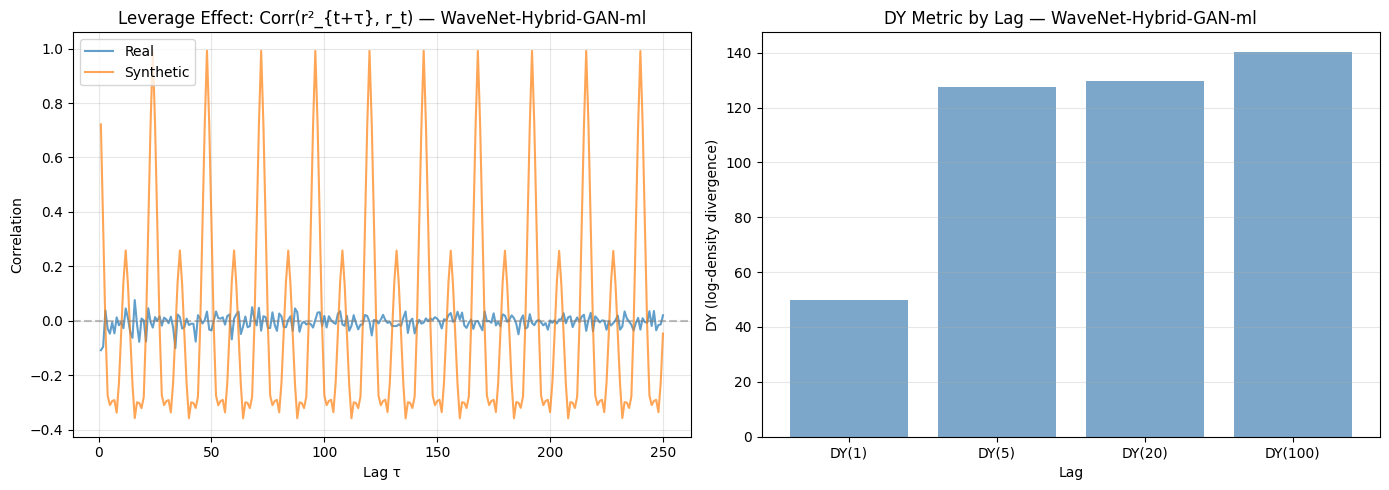

In [40]:
from utils.evaluation_metrics import (
    compute_dy_metric, compute_quantgan_acf_score, compute_leverage_effect_score
)

# Flatten to 1-D series for QuantGAN metrics
real_flat = real_2d.flatten()
synth_flat = synth_2d.flatten()

# --- DY Metric (multi-lag distributional divergence) ---
max_feasible_lag = min(len(real_flat), len(synth_flat)) // 2
dy_lags = tuple(l for l in (1, 5, 20, 100) if l < max_feasible_lag)
dy_results = compute_dy_metric(real_flat, synth_flat, lags=dy_lags)

print("=" * 65)
print(f"  {MODEL_NAME} — QuantGAN Metrics (Wiese et al., 2020)")
print("=" * 65)
print(f"\n  DY Metric (log-density divergence, lower = better):")
for key, val in dy_results.items():
    print(f"    {key:<12} {val:>10.4f}")

# --- ACF Score (3-transform) ---
# A) MinMax-scaled windowed data (our evaluation space)
qacf = compute_quantgan_acf_score(real_2d, synth_2d, max_lag=250)

print(f"\n  ACF Score — MinMax [0,1] windowed ({qacf['mode']}, "
      f"K={qacf['max_lag']} lags):")
print(f"    {'Metric':<30} {'L2 (QuantGAN)':>12} {'MSE (MiT-WGAN)':>14}")
print(f"    {'-'*56}")
print(f"    {'ACF(x)  — serial':<30} {qacf['acf_identity']:>12.4f} {qacf['acf_identity_mse']:>14.2e}")
print(f"    {'ACF(x²) — squared':<30} {qacf['acf_squared']:>12.4f} {qacf['acf_squared_mse']:>14.2e}")
print(f"    {'ACF(|x|) — absolute':<30} {qacf['acf_absolute']:>12.4f} {qacf['acf_absolute_mse']:>14.2e}")

# B) Original log-return scale — directly comparable to QuantGAN/MiT-WGAN
#    papers which compute on raw returns, not MinMax-scaled data
real_orig_2d = scaler.inverse_transform(real_2d.reshape(-1, 1)).reshape(real_2d.shape)
synth_orig_2d = scaler.inverse_transform(synth_2d.reshape(-1, 1)).reshape(synth_2d.shape)
qacf_orig = compute_quantgan_acf_score(real_orig_2d, synth_orig_2d, max_lag=250)

print(f"\n  ACF Score — Original log-returns ({qacf_orig['mode']}, "
      f"K={qacf_orig['max_lag']} lags):")
print(f"    {'Metric':<30} {'L2 (QuantGAN)':>12} {'MSE (MiT-WGAN)':>14}")
print(f"    {'-'*56}")
print(f"    {'ACF(x)  — serial':<30} {qacf_orig['acf_identity']:>12.4f} {qacf_orig['acf_identity_mse']:>14.2e}")
print(f"    {'ACF(x²) — squared':<30} {qacf_orig['acf_squared']:>12.4f} {qacf_orig['acf_squared_mse']:>14.2e}")
print(f"    {'ACF(|x|) — absolute':<30} {qacf_orig['acf_absolute']:>12.4f} {qacf_orig['acf_absolute_mse']:>14.2e}")

# C) Original log-returns, contiguous, 250 lags (QuantGAN paper setup)
real_orig_flat = scaler.inverse_transform(real_flat.reshape(-1, 1)).flatten()
synth_orig_flat = scaler.inverse_transform(synth_flat.reshape(-1, 1)).flatten()
qacf_cont = compute_quantgan_acf_score(real_orig_flat, synth_orig_flat, max_lag=250)

print(f"\n  ACF Score — Original log-returns ({qacf_cont['mode']}, "
      f"K={qacf_cont['max_lag']} lags, N={len(real_orig_flat)} pts):")
print(f"    {'Metric':<30} {'L2 (QuantGAN)':>12} {'MSE (MiT-WGAN)':>14}")
print(f"    {'-'*56}")
print(f"    {'ACF(x)  — serial':<30} {qacf_cont['acf_identity']:>12.4f} {qacf_cont['acf_identity_mse']:>14.2e}")
print(f"    {'ACF(x²) — squared':<30} {qacf_cont['acf_squared']:>12.4f} {qacf_cont['acf_squared_mse']:>14.2e}")
print(f"    {'ACF(|x|) — absolute':<30} {qacf_cont['acf_absolute']:>12.4f} {qacf_cont['acf_absolute_mse']:>14.2e}")

# --- Leverage Effect Score ---
lev = compute_leverage_effect_score(real_flat, synth_flat,
                                     max_lag=min(250, len(real_flat) // 4))

print(f"\n  Leverage Effect Score (L2, lower = better):")
print(f"    {'Score':<30} {lev['leverage_score']:>10.4f}")
print("=" * 65)

# --- Plot leverage effect curves ---
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Leverage effect
lags_lev = np.arange(1, len(lev['leverage_real']) + 1)
axes[0].plot(lags_lev, lev['leverage_real'], label='Real', alpha=0.7)
axes[0].plot(lags_lev, lev['leverage_synth'], label='Synthetic', alpha=0.7)
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title(f'Leverage Effect: Corr(r²_{{t+τ}}, r_t) — {MODEL_NAME}')
axes[0].set_xlabel('Lag τ')
axes[0].set_ylabel('Correlation')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# DY metric bar chart
dy_keys = list(dy_results.keys())
dy_vals = list(dy_results.values())
axes[1].bar(dy_keys, dy_vals, alpha=0.7, color='steelblue')
axes[1].set_title(f'DY Metric by Lag — {MODEL_NAME}')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('DY (log-density divergence)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 5d. Stylized Facts Metrics (Bouchaud et al. / Econophysics)

Three additional metrics based on canonical econophysics literature:

- **Leverage Effect (Bouchaud, 2001)** — Uses the original formulation: $L(t) = \frac{E[r_s \cdot |r_{s+t}|^2] - E[r] \cdot E[|r|^2]}{(E[|r|^2])^2}$. Preserves magnitude (not correlation-normalized like QuantGAN).
- **Volatility Clustering ACF** — ACF of $|r|$ with power-law decay estimation. Financial returns typically show slow decay $\sim k^{-0.3}$ (Cont, 2001).
- **Tail Distribution Metrics** — PDF comparison, tail mass ratios (5%/1%), and Hill estimator for power-law tail index $\alpha$ (typically $\alpha \approx 3{-}4$ for financial returns).

In [41]:
from utils.evaluation_metrics import (
    compute_leverage_effect_bouchaud, compute_volatility_clustering_acf,
    compute_tail_distribution_metrics
)

# --- Bouchaud Leverage Effect ---
lev_bouchaud = compute_leverage_effect_bouchaud(real_flat, synth_flat,
                                                  min_lag=1, max_lag=100)

# --- Volatility Clustering ACF (absolute returns) ---
vol_acf = compute_volatility_clustering_acf(real_flat, synth_flat,
                                             max_lag=min(500, len(real_flat) // 4),
                                             for_abs=True)

# --- Tail Distribution Metrics ---
tail_dist = compute_tail_distribution_metrics(real_flat, synth_flat,
                                               n_bins=100, normalize=True)

print("=" * 65)
print(f"  {MODEL_NAME} — Stylized Facts Metrics (Econophysics)")
print("=" * 65)

print(f"\n  Bouchaud Leverage Effect (L2 norm, lower = better):")
print(f"    {'Score':<35} {lev_bouchaud['leverage_score_bouchaud']:>10.4f}")

print(f"\n  Volatility Clustering ACF (|r| autocorrelation):")
print(f"    {'ACF Score (L2)':<35} {vol_acf['acf_score']:>10.4f}")
print(f"    {'RMSE':<35} {vol_acf['acf_rmse']:>10.4f}")
print(f"    {'Decay exponent (real) α':<35} {vol_acf['decay_real']:>10.4f}")
print(f"    {'Decay exponent (synth) α':<35} {vol_acf['decay_synth']:>10.4f}")
print(f"    {'(typical: α ≈ 0.2–0.4)':<35}")

print(f"\n  Tail Distribution Metrics:")
print(f"    {'PDF RMSE':<35} {tail_dist['pdf_rmse']:>10.6f}")
print(f"    {'Tail ratio 5% → 1.0':<35} {tail_dist['tail_ratio_5']:>10.4f}")
print(f"    {'Tail ratio 1% → 1.0':<35} {tail_dist['tail_ratio_1']:>10.4f}")
print(f"    {'Kurtosis (real)':<35} {tail_dist['kurtosis_real']:>10.4f}")
print(f"    {'Kurtosis (synth)':<35} {tail_dist['kurtosis_synth']:>10.4f}")
print(f"    {'Hill index α (real)':<35} {tail_dist['hill_real']:>10.4f}")
print(f"    {'Hill index α (synth)':<35} {tail_dist['hill_synth']:>10.4f}")
print(f"    {'(typical: Hill α ≈ 3–4)':<35}")
print("=" * 65)

  WaveNet-Hybrid-GAN-ml — Stylized Facts Metrics (Econophysics)

  Bouchaud Leverage Effect (L2 norm, lower = better):
    Score                                   0.6819

  Volatility Clustering ACF (|r| autocorrelation):
    ACF Score (L2)                          8.3854
    RMSE                                    0.3750
    Decay exponent (real) α                 0.2689
    Decay exponent (synth) α                0.0062
    (typical: α ≈ 0.2–0.4)             

  Tail Distribution Metrics:
    PDF RMSE                              0.048355
    Tail ratio 5% → 1.0                     0.0250
    Tail ratio 1% → 1.0                     0.0000
    Kurtosis (real)                         7.6192
    Kurtosis (synth)                       -1.8905
    Hill index α (real)                     2.8987
    Hill index α (synth)                   11.3278
    (typical: Hill α ≈ 3–4)            


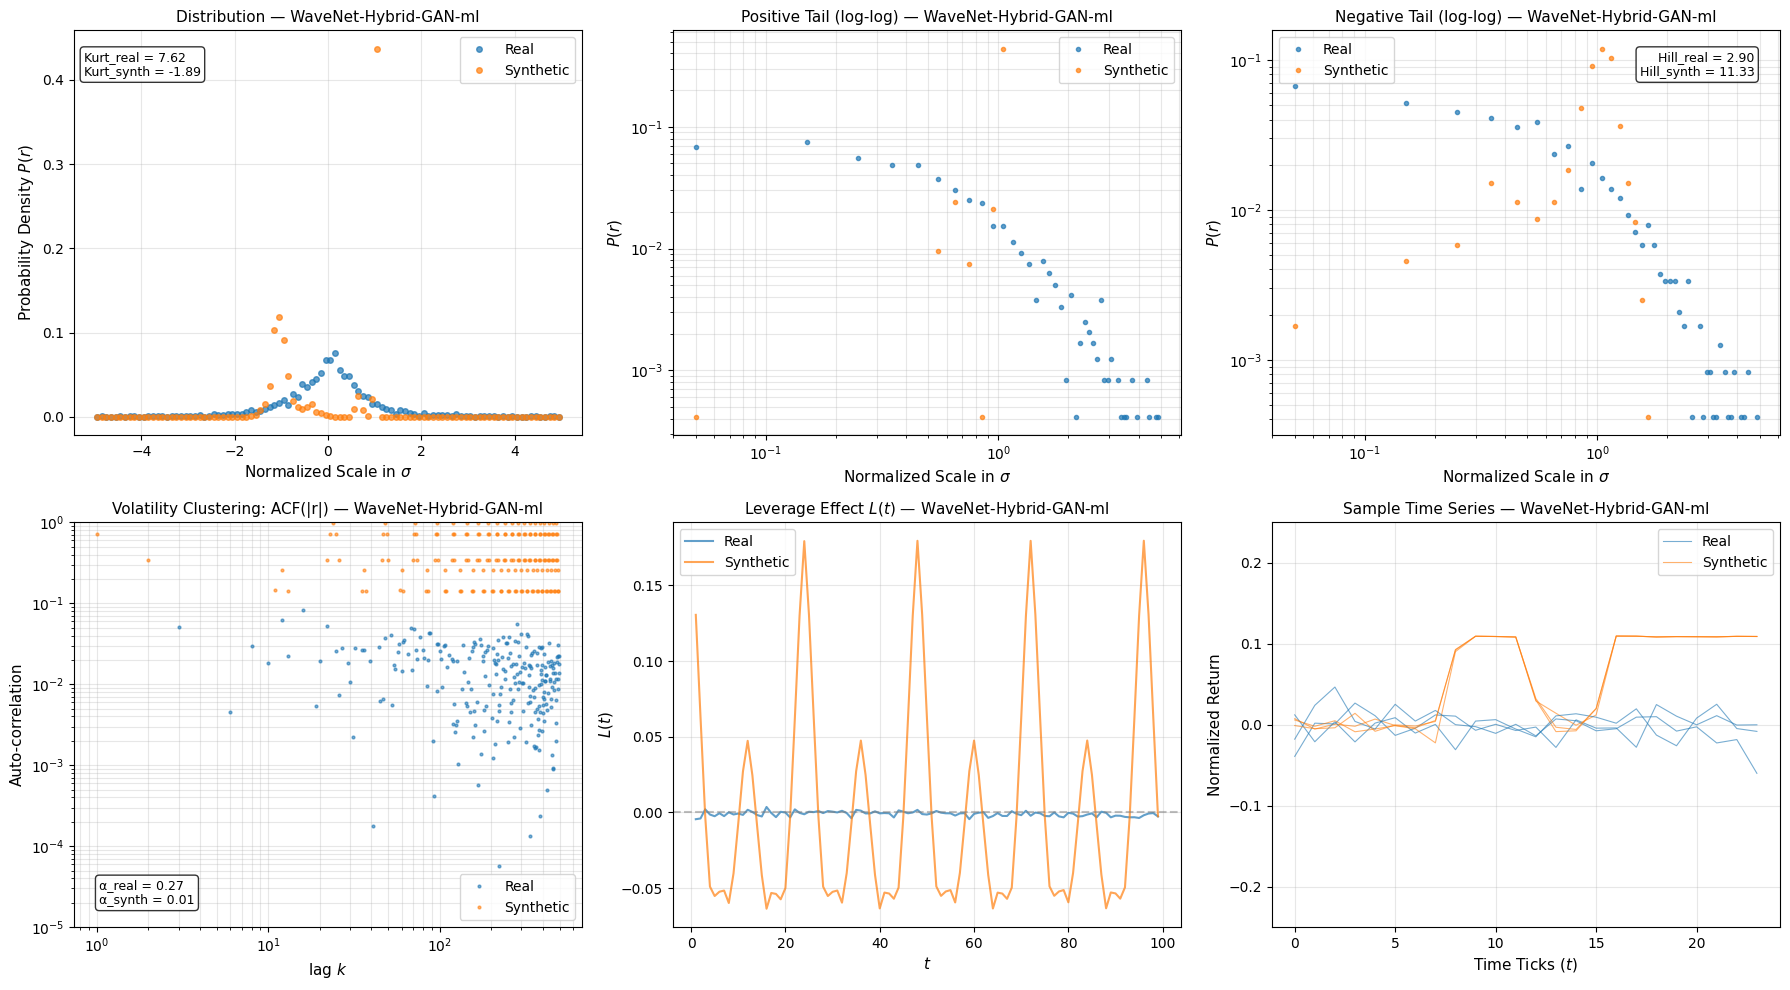

In [42]:
# --- Stylized Facts Plots (matching Wiese et al., 2020 Physica A figures) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ──────────────────────────────────────────────────────────
# 1. Distribution / PDF (paper Fig 3: linear axes, dot markers)
# ──────────────────────────────────────────────────────────
axes[0, 0].plot(tail_dist['pdf_x'], tail_dist['pdf_real'], 
                '.', markersize=8, alpha=0.7, label='Real')
axes[0, 0].plot(tail_dist['pdf_x'], tail_dist['pdf_synth'], 
                '.', markersize=8, alpha=0.7, label='Synthetic')
axes[0, 0].set_title(f'Distribution — {MODEL_NAME}', fontsize=11)
axes[0, 0].set_xlabel(r'Normalized Scale in $\sigma$', fontsize=11)
axes[0, 0].set_ylabel(r'Probability Density $P(r)$', fontsize=11)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].text(0.02, 0.95, 
                f"Kurt_real = {tail_dist['kurtosis_real']:.2f}\n"
                f"Kurt_synth = {tail_dist['kurtosis_synth']:.2f}",
                transform=axes[0, 0].transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ──────────────────────────────────────────────────────────
# 2. Positive tail (paper Fig 4 top: log-log, positive returns)
# ──────────────────────────────────────────────────────────
pdf_x = tail_dist['pdf_x']
pdf_real = tail_dist['pdf_real']
pdf_synth = tail_dist['pdf_synth']

pos_mask = pdf_x > 0
pos_x = pdf_x[pos_mask]
pos_real = pdf_real[pos_mask]
pos_synth = pdf_synth[pos_mask]
# Filter out zeros for log-log
pos_real_mask = pos_real > 0
pos_synth_mask = pos_synth > 0

axes[0, 1].plot(pos_x[pos_real_mask], pos_real[pos_real_mask], 
                '.', markersize=6, alpha=0.7, label='Real')
axes[0, 1].plot(pos_x[pos_synth_mask], pos_synth[pos_synth_mask], 
                '.', markersize=6, alpha=0.7, label='Synthetic')
axes[0, 1].set_xscale('log')
axes[0, 1].set_yscale('log')
axes[0, 1].set_title(f'Positive Tail (log-log) — {MODEL_NAME}', fontsize=11)
axes[0, 1].set_xlabel(r'Normalized Scale in $\sigma$', fontsize=11)
axes[0, 1].set_ylabel(r'$P(r)$', fontsize=11)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, which='both')

# ──────────────────────────────────────────────────────────
# 3. Negative tail (paper Fig 4 bottom: log-log, |negative| returns)
# ──────────────────────────────────────────────────────────
neg_mask = pdf_x < 0
neg_x = -pdf_x[neg_mask]  # flip sign for log scale
neg_real = pdf_real[neg_mask]
neg_synth = pdf_synth[neg_mask]
neg_real_mask = neg_real > 0
neg_synth_mask = neg_synth > 0

axes[0, 2].plot(neg_x[neg_real_mask], neg_real[neg_real_mask], 
                '.', markersize=6, alpha=0.7, label='Real')
axes[0, 2].plot(neg_x[neg_synth_mask], neg_synth[neg_synth_mask], 
                '.', markersize=6, alpha=0.7, label='Synthetic')
axes[0, 2].set_xscale('log')
axes[0, 2].set_yscale('log')
axes[0, 2].set_title(f'Negative Tail (log-log) — {MODEL_NAME}', fontsize=11)
axes[0, 2].set_xlabel(r'Normalized Scale in $\sigma$', fontsize=11)
axes[0, 2].set_ylabel(r'$P(r)$', fontsize=11)
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3, which='both')
# Hill annotation spanning both tail plots
axes[0, 2].text(0.95, 0.95, 
                f"Hill_real = {tail_dist['hill_real']:.2f}\n"
                f"Hill_synth = {tail_dist['hill_synth']:.2f}",
                transform=axes[0, 2].transAxes, fontsize=9, verticalalignment='top',
                horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ──────────────────────────────────────────────────────────
# 4. Volatility Clustering ACF (paper Fig 5: log-log scatter)
# ──────────────────────────────────────────────────────────
acf_lags = np.arange(1, len(vol_acf['acf_real']) + 1)
mask_r = vol_acf['acf_real'] > 0
mask_s = vol_acf['acf_synth'] > 0
axes[1, 0].plot(acf_lags[mask_r], vol_acf['acf_real'][mask_r], 
                '.', markersize=4, alpha=0.6, label='Real')
axes[1, 0].plot(acf_lags[mask_s], vol_acf['acf_synth'][mask_s], 
                '.', markersize=4, alpha=0.6, label='Synthetic')
axes[1, 0].set_xscale('log')
axes[1, 0].set_yscale('log')
axes[1, 0].set_ylim(1e-5, 1.0)
axes[1, 0].set_title(f'Volatility Clustering: ACF(|r|) — {MODEL_NAME}', fontsize=11)
axes[1, 0].set_xlabel(r'lag $k$', fontsize=11)
axes[1, 0].set_ylabel('Auto-correlation', fontsize=11)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, which='both')
axes[1, 0].text(0.05, 0.05, 
                f"α_real = {vol_acf['decay_real']:.2f}\nα_synth = {vol_acf['decay_synth']:.2f}",
                transform=axes[1, 0].transAxes, fontsize=9, verticalalignment='bottom',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ──────────────────────────────────────────────────────────
# 5. Leverage Effect (paper Fig 6: linear axes)
# ──────────────────────────────────────────────────────────
lags_b = lev_bouchaud['lags']
axes[1, 1].plot(lags_b, lev_bouchaud['leverage_real'], label='Real', alpha=0.7, linewidth=1.5)
axes[1, 1].plot(lags_b, lev_bouchaud['leverage_synth'], label='Synthetic', alpha=0.7, linewidth=1.5)
axes[1, 1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].set_title(f'Leverage Effect $L(t)$ — {MODEL_NAME}', fontsize=11)
axes[1, 1].set_xlabel(r'$t$', fontsize=11)
axes[1, 1].set_ylabel(r'$L(t)$', fontsize=11)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# ──────────────────────────────────────────────────────────
# 6. Sample time series (paper Fig — normalized returns)
# ──────────────────────────────────────────────────────────
# Plot a few real and synthetic series in original return space
real_flat_plot = scaler.inverse_transform(real_2d[:3].reshape(-1, 1)).reshape(3, SEQ_LEN)
synth_flat_plot = scaler.inverse_transform(synth_2d[:3].reshape(-1, 1)).reshape(3, SEQ_LEN)
for i in range(3):
    axes[1, 2].plot(real_flat_plot[i], alpha=0.6, color='C0', linewidth=0.8,
                    label='Real' if i == 0 else None)
    axes[1, 2].plot(synth_flat_plot[i], alpha=0.6, color='C1', linewidth=0.8,
                    label='Synthetic' if i == 0 else None)
axes[1, 2].set_ylim(-0.25, 0.25)
axes[1, 2].set_title(f'Sample Time Series — {MODEL_NAME}', fontsize=11)
axes[1, 2].set_xlabel(r'Time Ticks ($t$)', fontsize=11)
axes[1, 2].set_ylabel('Normalized Return', fontsize=11)
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Summary Dashboard

All scalar metrics in one table.

In [43]:
ch = list(tail_results['mean_diff'].keys())[0]

print("=" * 65)
print(f"  {MODEL_NAME} — Evaluation Summary")
print("=" * 65)
print(f"  {'Metric':<45} {'Value':>12}")
print("-" * 65)

# Distribution fidelity
print(f"  {'MMD (multi-scale RBF) ↓':<45} {mmd_results['mean']:>12.6f}")
print(f"  {'Wasserstein-1 ↓':<45} {dist_results['mean_wasserstein']:>12.6f}")
print(f"  {'KS statistic ↓':<45} {dist_results['mean_ks']:>12.4f}")
print(f"  {'KS p-value ↑':<45} {list(dist_results['ks_pvalue'].values())[0]:>12.4f}")
print(f"  {'JS divergence ↓':<45} {js_divergence:>12.6f}")

# Temporal dynamics
print(f"  {'ACF RMSE (returns) ↓':<45} {ret['rmse']:>12.6f}")
print(f"  {'ACF RMSE (squared returns) ↓':<45} {sq['rmse']:>12.6f}")

# Geometric
print(f"  {'Fréchet Distance (joint) ↓':<45} {fd_results['overall_fd']:>12.6f}")
print(f"  {'DTW distance (mean) ↓':<45} {dtw_score:>12.6f}")

# Tail metrics
print(f"  {'Mean diff → 0':<45} {tail_results['mean_diff'][ch]:>12.6f}")
print(f"  {'Std ratio → 1.0':<45} {tail_results['std_ratio'][ch]:>12.4f}")
print(f"  {'Skewness diff → 0':<45} {tail_results['skew_diff'][ch]:>12.4f}")
print(f"  {'Kurtosis diff → 0':<45} {tail_results['kurtosis_diff'][ch]:>12.4f}")

# Discriminative (MLP)
print(f"  {'MLP Disc. score ↓':<45} {disc_results['score']:>12.4f}")
print(f"  {'MLP Disc. accuracy → 0.5':<45} {disc_results['accuracy']:>12.4f}")

# GRU classifier (fidelity)
print(f"  {'GRU Disc. score ↓':<45} {gru_disc_score:>12.4f}")
print(f"  {'GRU Disc. accuracy → 0.5':<45} {gru_test_acc:>12.4f}")
print(f"  {'GRU AUC → 0.5':<45} {gru_test_auc:>12.4f}")

# TSTR (usefulness)
print(f"  {'TSTR MAE (Synth→Real) ↓':<45} {tstr_mae:>12.6f}")
print(f"  {'TRTR MAE (Real→Real) ↓':<45} {trtr_mae:>12.6f}")
print(f"  {'TSTR/TRTR ratio → 1.0':<45} {tstr_mae / trtr_mae:>12.4f}")

# Entropy (information-theoretic)
_ech = list(entropy_results['shannon_real'].keys())[0]
print(f"  {'Shannon Entropy |Δ| (bits) ↓':<45} {entropy_results['shannon_diff'][_ech]:>12.4f}")
print(f"  {'Lempel-Ziv Complexity |Δ| ↓':<45} {entropy_results['lz_diff'][_ech]:>12.4f}")
print(f"  {'Plug-in Entropy w=2 |Δ| (bits) ↓':<45} {entropy_results['plugin2_diff'][_ech]:>12.4f}")

# QuantGAN-style metrics (Wiese et al., 2020)
for key, val in dy_results.items():
    print(f"  {f'{key} (log-density div.) ↓':<45} {val:>12.4f}")

# ACF — MinMax [0,1] windowed
print(f"  {'--- ACF (MinMax, windowed) ---':<45}")
print(f"  {'ACF(id) L2 ↓':<45} {qacf['acf_identity']:>12.4f}")
print(f"  {'ACF(x²) L2 ↓':<45} {qacf['acf_squared']:>12.4f}")
print(f"  {'ACF(|x|) L2 ↓':<45} {qacf['acf_absolute']:>12.4f}")

# ACF — Original log-returns windowed (paper-comparable)
print(f"  {'--- ACF (log-returns, windowed) ---':<45}")
print(f"  {'ACF(id) L2 ↓':<45} {qacf_orig['acf_identity']:>12.4f}")
print(f"  {'ACF(x²) L2 ↓':<45} {qacf_orig['acf_squared']:>12.4f}")
print(f"  {'ACF(|x|) L2 ↓':<45} {qacf_orig['acf_absolute']:>12.4f}")

# ACF — Original log-returns contiguous (QuantGAN paper setup)
print(f"  {'--- ACF (log-returns, contiguous) ---':<45}")
print(f"  {'ACF(id) L2 ↓':<45} {qacf_cont['acf_identity']:>12.4f}")
print(f"  {'ACF(id) MSE ↓':<45} {qacf_cont['acf_identity_mse']:>12.2e}")
print(f"  {'ACF(x²) L2 ↓':<45} {qacf_cont['acf_squared']:>12.4f}")
print(f"  {'ACF(x²) MSE ↓':<45} {qacf_cont['acf_squared_mse']:>12.2e}")
print(f"  {'ACF(|x|) L2 ↓':<45} {qacf_cont['acf_absolute']:>12.4f}")
print(f"  {'ACF(|x|) MSE ↓':<45} {qacf_cont['acf_absolute_mse']:>12.2e}")

print(f"  {'Leverage Effect Score ↓':<45} {lev['leverage_score']:>12.4f}")

# Stylized Facts (Bouchaud et al. / Econophysics)
print(f"  {'Bouchaud Leverage Score ↓':<45} {lev_bouchaud['leverage_score_bouchaud']:>12.4f}")
print(f"  {'Vol Clustering ACF Score ↓':<45} {vol_acf['acf_score']:>12.4f}")
print(f"  {'Vol Clustering Decay α (real)':<45} {vol_acf['decay_real']:>12.4f}")
print(f"  {'Vol Clustering Decay α (synth)':<45} {vol_acf['decay_synth']:>12.4f}")
print(f"  {'PDF RMSE ↓':<45} {tail_dist['pdf_rmse']:>12.6f}")
print(f"  {'Tail ratio 5% → 1.0':<45} {tail_dist['tail_ratio_5']:>12.4f}")
print(f"  {'Tail ratio 1% → 1.0':<45} {tail_dist['tail_ratio_1']:>12.4f}")
print(f"  {'Hill index α (real)':<45} {tail_dist['hill_real']:>12.4f}")
print(f"  {'Hill index α (synth)':<45} {tail_dist['hill_synth']:>12.4f}")

print("=" * 65)
print(f"\n  Scale: MinMaxScaled [0,1] | Windows: non-overlapping (stride={SEQ_LEN})")
print(f"  Preprocessing: {PREPROCESSING}")
print(f"  Samples: {n_eval} real, {n_eval} synthetic | Noise: {NOISE_TYPE}")

  WaveNet-Hybrid-GAN-ml — Evaluation Summary
  Metric                                               Value
-----------------------------------------------------------------
  MMD (multi-scale RBF) ↓                           0.823072
  Wasserstein-1 ↓                                   0.235381
  KS statistic ↓                                      0.5167
  KS p-value ↑                                        0.0000
  JS divergence ↓                                   0.572466
  ACF RMSE (returns) ↓                              0.365612
  ACF RMSE (squared returns) ↓                      0.363369
  Fréchet Distance (joint) ↓                        0.081792
  DTW distance (mean) ↓                            21.422676
  Mean diff → 0                                     0.235381
  Std ratio → 1.0                                     3.7205
  Skewness diff → 0                                   0.0177
  Kurtosis diff → 0                                   9.5097
  MLP Disc. score ↓                

## 7. Evaluation Logging & Comparison

Append all metrics to a CSV file for tracking progress across model iterations.
Run this cell after each evaluation to build a comparison dataset.

In [44]:
import datetime
import os

# ============================================================
# Build metrics dictionary for this evaluation run
# ============================================================
eval_record = {
    # Run metadata
    'timestamp': datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'model_name': MODEL_NAME,
    'generator_path': os.path.basename(GENERATOR_PATH),
    'preprocessing': PREPROCESSING,
    'noise_type': NOISE_TYPE,
    'seq_len': SEQ_LEN,
    'n_samples': n_eval,
    
    # Distribution fidelity
    'mmd': mmd_results['mean'],
    'wasserstein_1': dist_results['mean_wasserstein'],
    'ks_statistic': dist_results['mean_ks'],
    'ks_pvalue': list(dist_results['ks_pvalue'].values())[0],
    'js_divergence': js_divergence,
    
    # Temporal dynamics
    'acf_rmse_returns': ret['rmse'],
    'acf_rmse_squared': sq['rmse'],
    
    # Geometric
    'frechet_distance': fd_results['overall_fd'],
    'dtw_distance': dtw_score,
    
    # Tail metrics
    'mean_diff': tail_results['mean_diff'][ch],
    'std_ratio': tail_results['std_ratio'][ch],
    'skew_diff': tail_results['skew_diff'][ch],
    'kurtosis_diff': tail_results['kurtosis_diff'][ch],
    
    # Discriminative
    'mlp_disc_score': disc_results['score'],
    'mlp_disc_accuracy': disc_results['accuracy'],
    'gru_disc_score': gru_disc_score,
    'gru_disc_accuracy': gru_test_acc,
    'gru_auc': gru_test_auc,
    
    # TSTR
    'tstr_mae': tstr_mae,
    'trtr_mae': trtr_mae,
    'tstr_trtr_ratio': tstr_mae / trtr_mae,
    
    # Entropy
    'shannon_entropy_diff': entropy_results['shannon_diff'][_ech],
    'lz_complexity_diff': entropy_results['lz_diff'][_ech],
    'plugin_entropy_diff': entropy_results['plugin2_diff'][_ech],
    
    # QuantGAN metrics — DY
    'dy_lag1': dy_results.get('lag_1', np.nan),
    'dy_lag5': dy_results.get('lag_5', np.nan),
    'dy_lag20': dy_results.get('lag_20', np.nan),

    # ACF — MinMax [0,1] windowed (our evaluation space)
    'acf_identity': qacf['acf_identity'],
    'acf_squared': qacf['acf_squared'],
    'acf_absolute': qacf['acf_absolute'],

    # ACF — Original log-returns windowed (paper-comparable)
    'acf_orig_identity': qacf_orig['acf_identity'],
    'acf_orig_squared': qacf_orig['acf_squared'],
    'acf_orig_absolute': qacf_orig['acf_absolute'],

    # ACF — Original log-returns contiguous (QuantGAN paper setup)
    'acf_cont_identity_l2': qacf_cont['acf_identity'],
    'acf_cont_squared_l2': qacf_cont['acf_squared'],
    'acf_cont_absolute_l2': qacf_cont['acf_absolute'],
    'acf_cont_identity_mse': qacf_cont['acf_identity_mse'],
    'acf_cont_squared_mse': qacf_cont['acf_squared_mse'],
    'acf_cont_absolute_mse': qacf_cont['acf_absolute_mse'],

    'leverage_score': lev['leverage_score'],
    
    # Stylized facts (Bouchaud et al.)
    'bouchaud_leverage_score': lev_bouchaud['leverage_score_bouchaud'],
    'vol_clustering_acf_score': vol_acf['acf_score'],
    'vol_clustering_decay_real': vol_acf['decay_real'],
    'vol_clustering_decay_synth': vol_acf['decay_synth'],
    'pdf_rmse': tail_dist['pdf_rmse'],
    'tail_ratio_5pct': tail_dist['tail_ratio_5'],
    'tail_ratio_1pct': tail_dist['tail_ratio_1'],
    'hill_index_real': tail_dist['hill_real'],
    'hill_index_synth': tail_dist['hill_synth'],
}

# ============================================================
# Append to CSV — handles schema evolution safely
# Strip existing column names to prevent duplication from whitespace mismatch
# (old CSV had space-padded column names, causing "timestamp" ≠ "timestamp   ")
# ============================================================
EVAL_LOG_PATH = '../data/evaluation_log.csv'

eval_df = pd.DataFrame([eval_record])

if os.path.exists(EVAL_LOG_PATH):
    existing_df = pd.read_csv(EVAL_LOG_PATH)
    existing_df.columns = existing_df.columns.str.strip()  # prevent duplicate columns
    combined_df = pd.concat([existing_df, eval_df], ignore_index=True)
    combined_df.to_csv(EVAL_LOG_PATH, index=False)
    print(f"✓ Appended evaluation to {EVAL_LOG_PATH}")
    if len(eval_df.columns) > len(existing_df.columns):
        new_cols = set(eval_df.columns) - set(existing_df.columns)
        print(f"  ⚠ Added {len(new_cols)} new column(s): {', '.join(sorted(new_cols))}")
else:
    eval_df.to_csv(EVAL_LOG_PATH, mode='w', header=True, index=False)
    print(f"✓ Created {EVAL_LOG_PATH} with first evaluation")

print(f"  Model: {MODEL_NAME}")
print(f"  Timestamp: {eval_record['timestamp']}")

# Show current log count
log_df = pd.read_csv(EVAL_LOG_PATH)
print(f"  Total evaluations logged: {len(log_df)}")

✓ Appended evaluation to ../data/evaluation_log.csv
  Model: WaveNet-Hybrid-GAN-ml
  Timestamp: 2026-03-11 08:56:11
  Total evaluations logged: 13


Loaded 13 evaluation(s) from ../data/evaluation_log.csv



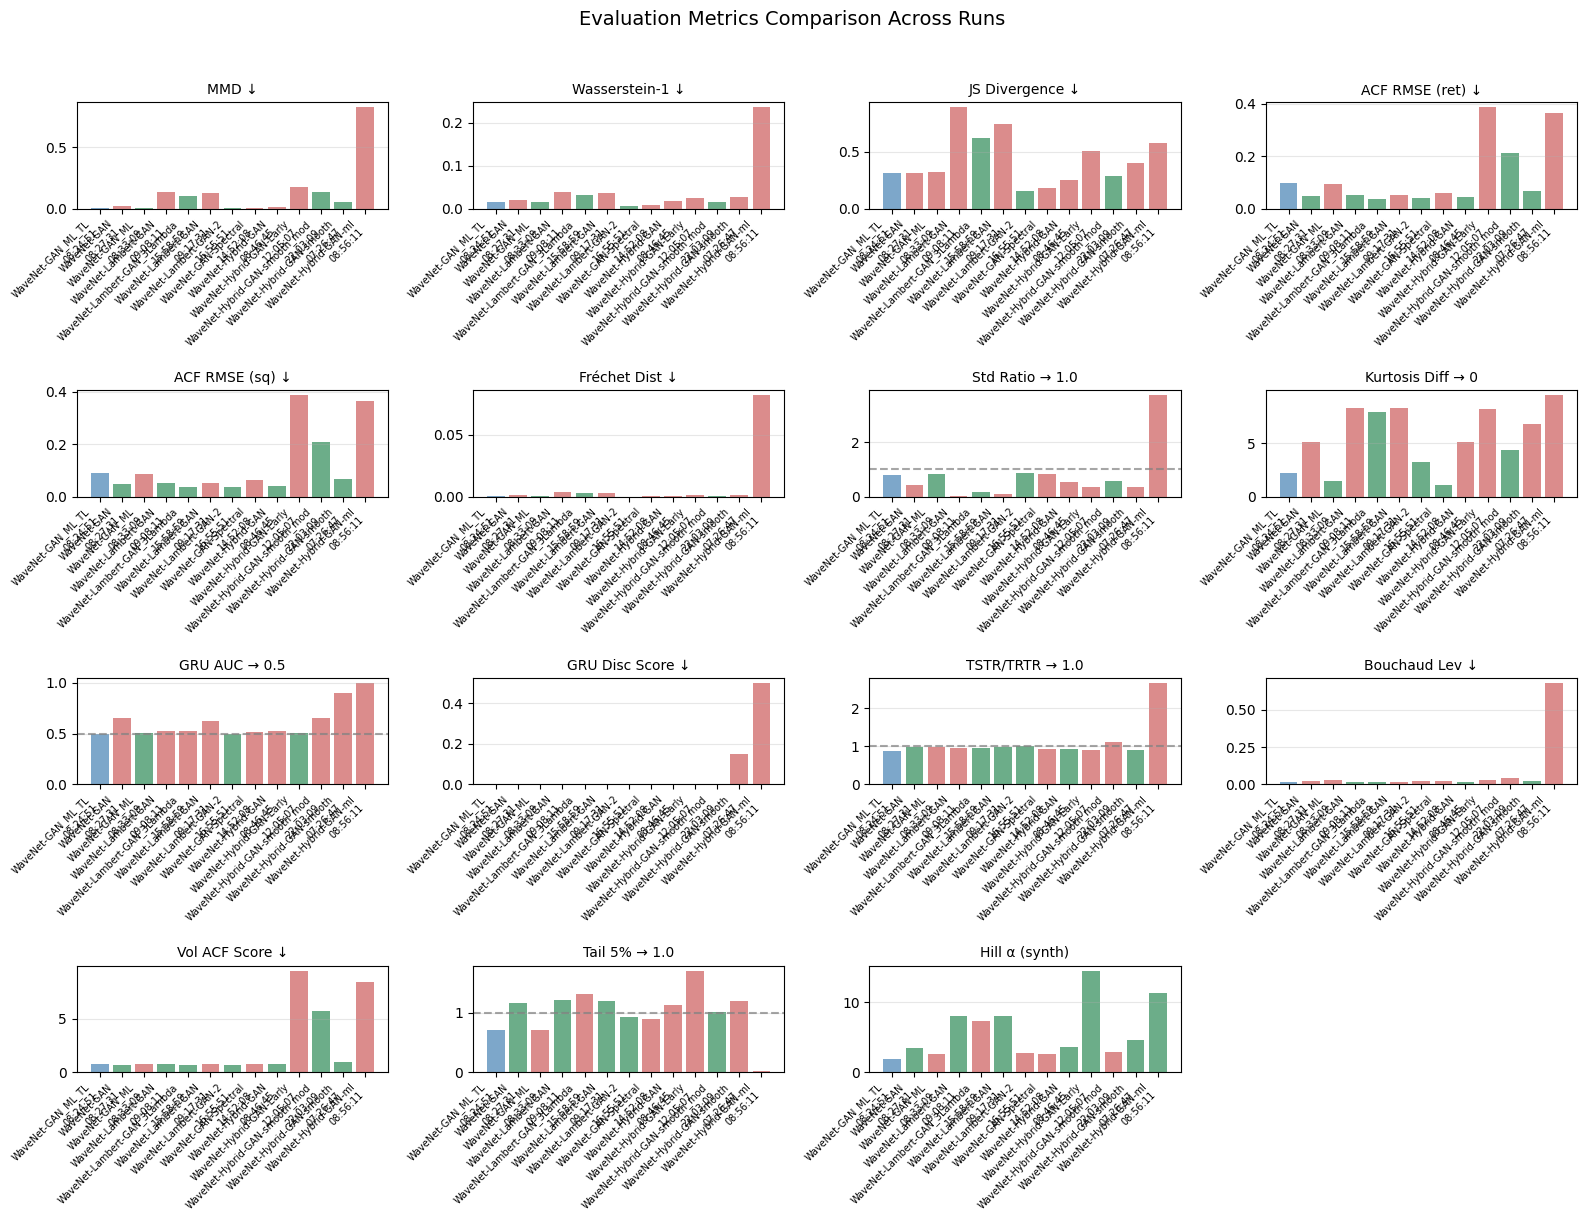


Recent Evaluations (last 5):
          timestamp                    model_name      mmd  gru_auc  std_ratio  kurtosis_diff  tstr_trtr_ratio
2026-03-08 08:46:45            WaveNet-Hybrid-GAN 0.018320   0.5225   0.524979       5.103106         0.936237
2026-03-08 12:05:07      WaveNet-Hybrid-GAN-Early 0.178830   0.5050   0.350108       8.191636         0.915186
2026-03-08 22:03:09 WaveNet-Hybrid-GAN-smooth_mod 0.140045   0.6500   0.571134       4.326594         1.124605
2026-03-09 07:26:47     WaveNet-Hybrid-GAN-smooth 0.053258   0.9000   0.352000       6.819996         0.914939
2026-03-11 08:56:11         WaveNet-Hybrid-GAN-ml 0.823072   1.0000   3.720505       9.509713         2.666816


In [45]:
# ============================================================
# Load and visualize evaluation history
# ============================================================
if not os.path.exists(EVAL_LOG_PATH):
    print("No evaluation log found. Run the logging cell first.")
else:
    log_df = pd.read_csv(EVAL_LOG_PATH)
    print(f"Loaded {len(log_df)} evaluation(s) from {EVAL_LOG_PATH}\n")
    
    # Key metrics to compare (lower is better unless noted)
    metrics_config = {
        # Distribution fidelity
        'mmd': {'label': 'MMD ↓', 'lower_better': True},
        'wasserstein_1': {'label': 'Wasserstein-1 ↓', 'lower_better': True},
        'js_divergence': {'label': 'JS Divergence ↓', 'lower_better': True},
        
        # Temporal
        'acf_rmse_returns': {'label': 'ACF RMSE (ret) ↓', 'lower_better': True},
        'acf_rmse_squared': {'label': 'ACF RMSE (sq) ↓', 'lower_better': True},
        
        # Geometric
        'frechet_distance': {'label': 'Fréchet Dist ↓', 'lower_better': True},
        
        # Tail
        'std_ratio': {'label': 'Std Ratio → 1.0', 'lower_better': False, 'target': 1.0},
        'kurtosis_diff': {'label': 'Kurtosis Diff → 0', 'lower_better': True},
        
        # Discriminative
        'gru_auc': {'label': 'GRU AUC → 0.5', 'lower_better': False, 'target': 0.5},
        'gru_disc_score': {'label': 'GRU Disc Score ↓', 'lower_better': True},
        
        # TSTR
        'tstr_trtr_ratio': {'label': 'TSTR/TRTR → 1.0', 'lower_better': False, 'target': 1.0},
        
        # Stylized facts
        'bouchaud_leverage_score': {'label': 'Bouchaud Lev ↓', 'lower_better': True},
        'vol_clustering_acf_score': {'label': 'Vol ACF Score ↓', 'lower_better': True},
        'tail_ratio_5pct': {'label': 'Tail 5% → 1.0', 'lower_better': False, 'target': 1.0},
        'hill_index_synth': {'label': 'Hill α (synth)', 'lower_better': False},
    }
    
    # Select metrics that exist in the log
    available_metrics = [m for m in metrics_config if m in log_df.columns]
    
    if len(log_df) >= 2:
        # Plot comparison across runs
        n_metrics = len(available_metrics)
        n_cols = 4
        n_rows = (n_metrics + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
        axes = axes.flatten()
        
        # X-axis: model names with timestamps (truncated, NaN-safe)
        x_labels = [f"{row['model_name']}\n{str(row['timestamp'])[-8:]}"
                    if pd.notna(row['timestamp'])
                    else str(row['model_name'])
                    for _, row in log_df.iterrows()]
        x = np.arange(len(log_df))
        
        for i, metric in enumerate(available_metrics):
            ax = axes[i]
            cfg = metrics_config[metric]
            values = log_df[metric].values
            
            # Color bars: green if improving, red if worsening
            colors = []
            for j, val in enumerate(values):
                if j == 0:
                    colors.append('steelblue')
                else:
                    prev = values[j - 1]
                    if 'target' in cfg:
                        # Closer to target is better
                        improved = abs(val - cfg['target']) < abs(prev - cfg['target'])
                    elif cfg['lower_better']:
                        improved = val < prev
                    else:
                        improved = val > prev
                    colors.append('seagreen' if improved else 'indianred')
            
            ax.bar(x, values, color=colors, alpha=0.7)
            ax.set_title(cfg['label'], fontsize=10)
            ax.set_xticks(x)
            ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=7)
            
            # Add target line if applicable
            if 'target' in cfg:
                ax.axhline(cfg['target'], color='gray', linestyle='--', alpha=0.7)
            
            ax.grid(True, alpha=0.3, axis='y')
        
        # Hide unused axes
        for j in range(len(available_metrics), len(axes)):
            axes[j].set_visible(False)
        
        plt.suptitle('Evaluation Metrics Comparison Across Runs', fontsize=14, y=1.02)
        plt.tight_layout()
        plt.show()
        
        # Summary table of recent runs
        print("\n" + "=" * 80)
        print("Recent Evaluations (last 5):")
        print("=" * 80)
        display_cols = ['timestamp', 'model_name', 'mmd', 'gru_auc', 'std_ratio', 
                        'kurtosis_diff', 'tstr_trtr_ratio']
        display_cols = [c for c in display_cols if c in log_df.columns]
        print(log_df[display_cols].tail(5).to_string(index=False))
    else:
        print("Only 1 evaluation in log. Run more evaluations to compare.")
        print(log_df.T)